/home/wojtek/PycharmProjects/my_first_ds_project/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Podobne do 'good':
[('bad', 0.7606037855148315), ('great', 0.7251434326171875), ('decent', 0.712730884552002), ('cool', 0.6374263167381287), ('nice', 0.6290174722671509)]

Podobne do 'bad':
[('good', 0.7606038451194763), ('terrible', 0.7375964522361755), ('awful', 0.7305787801742554), ('lame', 0.6819870471954346), ('horrible', 0.6793085336685181)]
[('performer', 0.6367473602294922), ('actress', 0.6299280524253845), ('role', 0.6070910692214966), ('artist', 0.6021014451980591), ('comedian', 0.5805389285087585)]


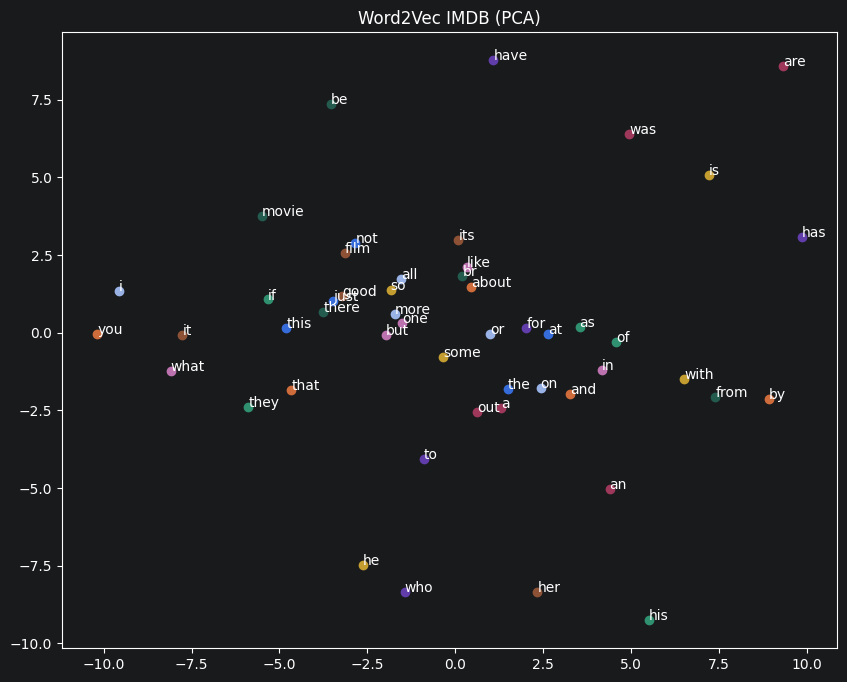

In [2]:
import re
from tensorflow.keras.datasets import imdb

# load (indeksy → słowa)
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(encoded):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded])

(x_train, _), _ = imdb.load_data(num_words=10000)

texts = [decode_review(x) for x in x_train]

# =========================
# preprocessing
# =========================
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text.split()

tokenized = [preprocess(t) for t in texts]

from gensim.models import Word2Vec

model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)

print("Podobne do 'good':")
print(model.wv.most_similar("good", topn=5))

print("\nPodobne do 'bad':")
print(model.wv.most_similar("bad", topn=5))

print(model.wv.most_similar(
    positive=["good", "actor"],
    negative=["bad"],
    topn=5
))

import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from collections import Counter

# najczęstsze słowa
all_words = [w for sent in tokenized for w in sent]
common_words = [w for w, _ in Counter(all_words).most_common(50)]

vectors = np.array([model.wv[w] for w in common_words if w in model.wv])

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(10,8))

for i, word in enumerate(common_words):
    if word in model.wv:
        plt.scatter(reduced[i,0], reduced[i,1])
        plt.text(reduced[i,0], reduced[i,1], word)

plt.title("Word2Vec IMDB (PCA)")
plt.show()